# Problema 2

In [ ]:
#Cargo codigo R en GCP (google colab enterprise)
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R

install.packages(c("ggplot2", "dplyr", "caret", "corrplot", "gridExtra"))


#cargar las distintas librerias
library(MASS) #lda
library(tidyr)
library(ggplot2) #graficos
library(dplyr) # manipulacion de datos
library(caret) # particion estratificada
library(corrplot) #matriz de correlacion
library(gridExtra) # cambinar multiples graficos

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/caret_7.0-1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.1.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpTg2zcc/downloaded_packages’


In [ ]:
#cargar el archivo desde GCS a la máquina virtual
%%R
system("gsutil cp 'gs://all-in-master/MÉTODOS ESTADÍSTICOS PARA LA CIENCIA DE DATOS/Datos_pacientes_respiratorios.csv' /tmp/Datos_pacientes_respiratorios.csv")

#leer el archivo
datos_pacientes <- read.csv("/tmp/Datos_pacientes_respiratorios.csv")

In [ ]:
%%R

#mostrar los primeros registros
head(datos_pacientes)

  Paciente         Diagnostico Edad Temperatura_C Saturacion_O2_pct
1    PX001     Viral_no_gripal   35          36.4              98.7
2    PX002           Influenza   65          38.6              96.1
3    PX003           Influenza   40          38.1              94.8
4    PX004     Viral_no_gripal   43          36.8             100.0
5    PX005     Crisis_asmatica   34          36.8              95.4
6    PX006 Neumonia_bacteriana   50          37.5              94.5
  Frecuencia_respiratoria Frecuencia_cardiaca Leucocitos_miles PCR_mg_L
1                      14                  70              4.7      2.8
2                      19                  93             10.5     15.9
3                      20                  87             11.3     31.8
4                      12                  73              6.9     10.2
5                      22                  72              4.2      0.2
6                      24                  84             10.9     20.3
  Dias_evolucion Int

In [ ]:
#ver todas las variables en el archivo
%%R
names(datos_pacientes)

 [1] "Paciente"                "Diagnostico"            
 [3] "Edad"                    "Temperatura_C"          
 [5] "Saturacion_O2_pct"       "Frecuencia_respiratoria"
 [7] "Frecuencia_cardiaca"     "Leucocitos_miles"       
 [9] "PCR_mg_L"                "Dias_evolucion"         
[11] "Intensidad_tos_0_10"     "Disnea_0_10"            
[13] "Flujo_espiratorio_pct"   "Fatiga_0_10"            


In [ ]:
%%R
#ver si hay datos nulos en el dataset
anyNA(datos_pacientes)

[1] FALSE


In [ ]:
%%R
#ver el tipo de dato de las variables
str(datos_pacientes)

'data.frame':	168 obs. of  14 variables:
 $ Paciente               : chr  "PX001" "PX002" "PX003" "PX004" ...
 $ Diagnostico            : chr  "Viral_no_gripal" "Influenza" "Influenza" "Viral_no_gripal" ...
 $ Edad                   : int  35 65 40 43 34 50 46 40 33 27 ...
 $ Temperatura_C          : num  36.4 38.6 38.1 36.8 36.8 37.5 37.9 36 39 35.8 ...
 $ Saturacion_O2_pct      : num  98.7 96.1 94.8 100 95.4 94.5 94.5 98.6 95.6 97 ...
 $ Frecuencia_respiratoria: int  14 19 20 12 22 24 20 16 21 17 ...
 $ Frecuencia_cardiaca    : int  70 93 87 73 72 84 87 66 88 66 ...
 $ Leucocitos_miles       : num  4.7 10.5 11.3 6.9 4.2 10.9 8.2 5.2 9.7 3.2 ...
 $ PCR_mg_L               : num  2.8 15.9 31.8 10.2 0.2 20.3 20.2 0.2 22.7 0.2 ...
 $ Dias_evolucion         : int  4 6 4 2 3 5 4 1 5 1 ...
 $ Intensidad_tos_0_10    : int  1 7 7 4 3 5 5 1 8 0 ...
 $ Disnea_0_10            : int  0 4 3 0 5 3 4 2 4 3 ...
 $ Flujo_espiratorio_pct  : num  100.9 84.7 82.7 125 64.3 ...
 $ Fatiga_0_10            : i

La unidad de observación es cada paciente (168 en total, identificados por la columna Paciente). La variable de grupo es Diagnostico, con cuatro clases: Influenza, Neumonia_bacteriana, Crisis_asmatica y Viral_no_gripal. Las 12 variables restantes (de Edad a Fatiga_0_10), todas numéricas, actúan como predictoras.



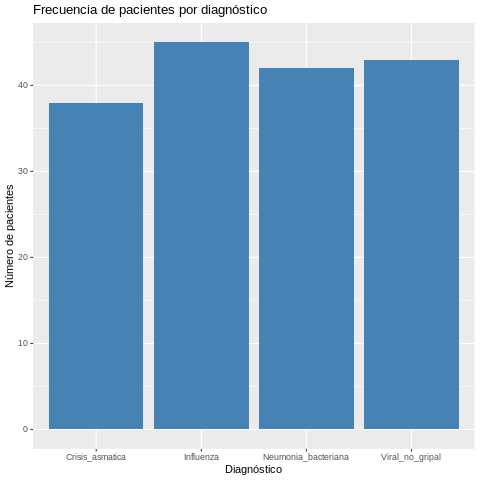

In [ ]:
%%R
#se genera una grafica de de barras para ver si las 4 clases estan balanceadas
ggplot(datos_pacientes, aes(x = Diagnostico)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Frecuencia de pacientes por diagnóstico",
       x = "Diagnóstico", y = "Número de pacientes")

La distribución de pacientes por diagnóstico no es perfectamente equilibrada, aunque tampoco presenta un desbalance severo entre clases. Influenza es el diagnóstico con mayor número de casos, mientras que Crisis asmática es el que menos pacientes registra. Neumonía bacteriana e Infección viral no gripal presentan una frecuencia similar entre sí, ubicándose en un nivel intermedio.

In [ ]:
%%R
#saco las variables que no son numericas
datos_numericos <- datos_pacientes %>% select(-Paciente, -Diagnostico)

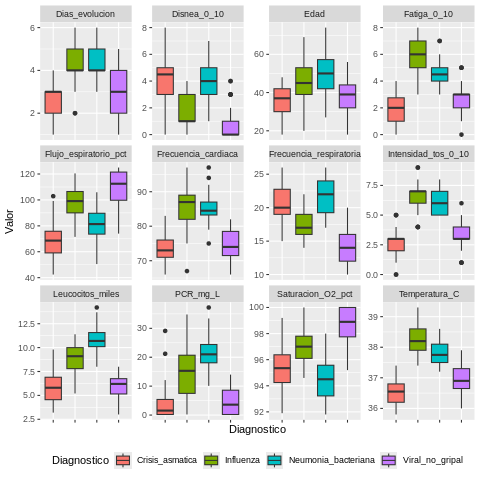

In [ ]:
%%R
#oxplots predictora vs diagnóstico, la exploración bivariada que falta
datos_long <- datos_pacientes %>%
  select(-Paciente) %>%
  pivot_longer(cols = -Diagnostico, names_to = "Variable", values_to = "Valor")

ggplot(datos_long, aes(x = Diagnostico, y = Valor, fill = Diagnostico)) +
  geom_boxplot() +
  facet_wrap(~ Variable, scales = "free_y") +
  theme(axis.text.x = element_blank(), legend.position = "bottom")

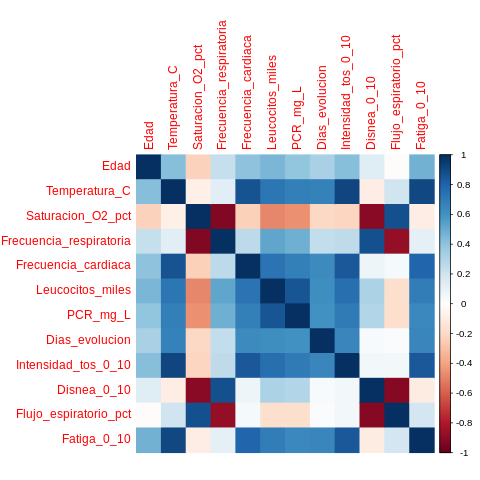

In [ ]:
%%R
#matriz de correlacion
matriz <- cor(datos_numericos)
corrplot(matriz, method = "color")

La matriz de correlación muestra algunas relaciones destacables entre las variables clínicas. Se observa una correlación positiva fuerte entre Intensidad_tos_0_10 y Fatiga_0_10, lo que sugiere que los pacientes con tos más intensa tienden a presentar también mayor fatiga. De forma similar, Temperatura_C y Frecuencia_cardiaca están correlacionadas positivamente, lo cual es coherente clínicamente: a mayor temperatura corporal, mayor frecuencia cardiaca. También se observa correlación positiva entre Saturacion_O2_pct y Flujo_espiratorio_pct.
Por otro lado, se identifican correlaciones negativas fuertes entre Saturacion_O2_pct y Frecuencia_respiratoria, y entre Saturacion_O2_pct y Disnea_0_10, lo cual también es clínicamente coherente: a menor saturación de oxígeno, mayor frecuencia respiratoria y mayor sensación de dificultad para respirar. De forma similar, Flujo_espiratorio_pct presenta relación inversa tanto con Frecuencia_respiratoria como con Disnea_0_10.
En conjunto, estas relaciones indican cierto grado de colinealidad entre las variables respiratorias (saturación, frecuencia respiratoria, disnea y flujo espiratorio), lo cual conviene tener presente al interpretar los resultados del análisis discriminante.

In [ ]:
%%R
#creo el data frame, pero incluyendo diafnostico (quitando a pacientes)
Datos_modelo <- datos_pacientes %>% select(-Paciente)

In [ ]:
%%R
#ajuste del modelo con la muestra completa
modelo <- lda(Diagnostico ~ ., data = Datos_modelo)

In [ ]:
%%R
#mostrar modelo
modelo

Call:
lda(Diagnostico ~ ., data = Datos_modelo)

Prior probabilities of groups:
    Crisis_asmatica           Influenza Neumonia_bacteriana     Viral_no_gripal 
          0.2261905           0.2678571           0.2500000           0.2559524 

Group means:
                        Edad Temperatura_C Saturacion_O2_pct
Crisis_asmatica     35.39474      36.50789          95.33684
Influenza           45.75556      38.26000          97.05333
Neumonia_bacteriana 49.02381      37.80238          94.48095
Viral_no_gripal     37.44186      36.96279          98.63023
                    Frecuencia_respiratoria Frecuencia_cardiaca
Crisis_asmatica                    20.36842            73.47368
Influenza                          17.40000            85.86667
Neumonia_bacteriana                21.88095            85.11905
Viral_no_gripal                    14.20930            74.81395
                    Leucocitos_miles  PCR_mg_L Dias_evolucion
Crisis_asmatica             5.842105  4.021053       2.50

Al haber 4 grupos, el modelo genera 3 funciones discriminantes. LD1 concentra el 57.6% de la capacidad de separación entre grupos, LD2 el 30.6% y LD3 el 11.8%, por lo que las dos primeras funciones explican en conjunto cerca del 88% de la separación.


In [ ]:
%%R
#prediciones sobre la muestra
predicciones <- predict(modelo)

#matriz de confusion
tabla_confusion <- table(Real = Datos_modelo$Diagnostico, Predicho = predicciones$class)
tabla_confusion

                     Predicho
Real                  Crisis_asmatica Influenza Neumonia_bacteriana
  Crisis_asmatica                  36         0                   0
  Influenza                         0        39                   2
  Neumonia_bacteriana               0         3                  39
  Viral_no_gripal                   4         1                   1
                     Predicho
Real                  Viral_no_gripal
  Crisis_asmatica                   2
  Influenza                         4
  Neumonia_bacteriana               0
  Viral_no_gripal                  37


In [ ]:
%%R
#precision global
precision <- sum(diag(tabla_confusion)) / sum(tabla_confusion)
precision

[1] 0.8988095


In [ ]:
%%R
 #armar el data frame de puntajes LD1-3 y hacer los grafucis de separacion
puntaje <- as.data.frame(predicciones$x)
puntaje$grupo <- Datos_modelo$Diagnostico

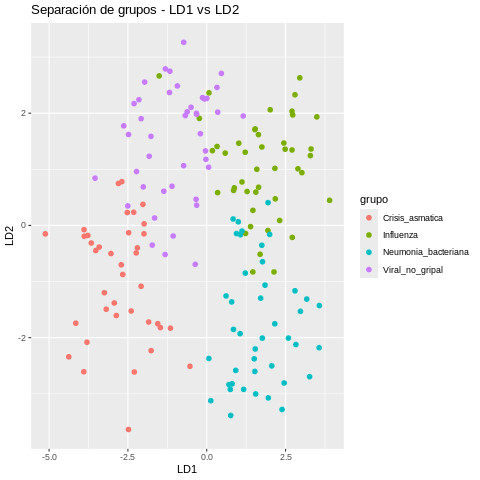

In [ ]:
%%R
#ggplot scatter LD1, y = LD2
ggplot(puntaje, aes(x = LD1, y = LD2, color = grupo)) +
  geom_point(size = 2) +
  labs(title = "Separación de grupos - LD1 vs LD2", x = "LD1", y = "LD2")

El gráfico de dispersión LD1 vs LD2 muestra que los grupos no están completamente separados entre sí, aunque se identifican patrones claros. Neumonia_bacteriana y Crisis_asmatica no se mezclan en ningún punto, lo cual es consistente con que la matriz de confusión no registró ningún caso de confusión entre estos dos diagnósticos. En cambio, Influenza se solapa parcialmente con Viral_no_gripal y, en menor medida, con Neumonia_bacteriana, coincidiendo con los errores observados en la matriz de confusión entre estos pares. De forma similar, Crisis_asmatica se relaciona levemente con Viral_no_gripal pero no con Neumonia_bacteriana.

Considerando que LD1 es la función discriminante que más aporta a la separación entre grupos (57.6% de la proporción de traza), se observa que esta dimensión distingue principalmente entre Crisis_asmatica/Viral_no_gripal (lado izquierdo) e Influenza/Neumonia_bacteriana (lado derecho)

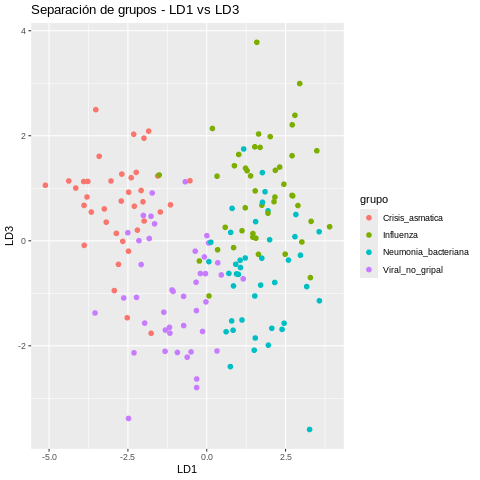

In [ ]:
%%R
#grafico con LD1 y LD3
ggplot(puntaje, aes(x = LD1, y = LD3, color = grupo)) +
  geom_point(size = 2) +
  labs(title = "Separación de grupos - LD1 vs LD3", x = "LD1", y = "LD3")

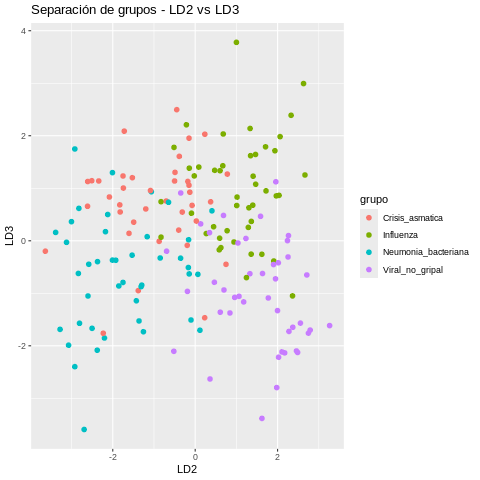

In [ ]:
%%R
#hago un grafico con los LD 2 + LS3
ggplot(puntaje, aes(x = LD2, y = LD3, color = grupo)) +
  geom_point(size = 2) +
  labs(title = "Separación de grupos - LD2 vs LD3", x = "LD2", y = "LD3")

In [ ]:
%%R

#hago la divicion del dataset
set.seed(123)
indices <- createDataPartition(Datos_modelo$Diagnostico, p = 0.7, list = FALSE)

entrenamiento <- Datos_modelo[indices, ]
prueba <- Datos_modelo[-indices, ]

Se fijó la semilla 123 para garantizar la reproducibilidad de la partición estratificada (70% entrenamiento, 30% prueba).



In [ ]:
%%R
#verifico que todo haya quedado bien (datos de entrenamiento  )
table(entrenamiento$Diagnostico)



    Crisis_asmatica           Influenza Neumonia_bacteriana     Viral_no_gripal 
                 27                  32                  30                  31 


In [ ]:
%%R
#verifico que todo haya quedo bien en el conjunto de prueba
table(prueba$Diagnostico)


    Crisis_asmatica           Influenza Neumonia_bacteriana     Viral_no_gripal 
                 11                  13                  12                  12 


In [ ]:
%%R
#entrenamos el modelo
modelo_train <- lda(Diagnostico ~ ., data = entrenamiento)
modelo_train

Call:
lda(Diagnostico ~ ., data = entrenamiento)

Prior probabilities of groups:
    Crisis_asmatica           Influenza Neumonia_bacteriana     Viral_no_gripal 
          0.2250000           0.2666667           0.2500000           0.2583333 

Group means:
                        Edad Temperatura_C Saturacion_O2_pct
Crisis_asmatica     34.66667      36.52222          95.21852
Influenza           45.96875      38.23750          97.18125
Neumonia_bacteriana 49.40000      37.82000          94.73000
Viral_no_gripal     37.19355      36.97097          98.51613
                    Frecuencia_respiratoria Frecuencia_cardiaca
Crisis_asmatica                    20.37037            73.66667
Influenza                          17.31250            85.18750
Neumonia_bacteriana                21.40000            84.93333
Viral_no_gripal                    14.38710            75.00000
                    Leucocitos_miles  PCR_mg_L Dias_evolucion
Crisis_asmatica             5.600000  3.822222       2.5

In [ ]:
%%R
#testeo el modelo con set de prueba e imprimo el resultado
predicciones_test <- predict(modelo_train, newdata = prueba)

tabla_confusion_test <- table(Real = prueba$Diagnostico, Predicho = predicciones_test$class)
tabla_confusion_test


                     Predicho
Real                  Crisis_asmatica Influenza Neumonia_bacteriana
  Crisis_asmatica                   9         0                   0
  Influenza                         0        11                   1
  Neumonia_bacteriana               0         1                  11
  Viral_no_gripal                   0         2                   0
                     Predicho
Real                  Viral_no_gripal
  Crisis_asmatica                   2
  Influenza                         1
  Neumonia_bacteriana               0
  Viral_no_gripal                  10


In [ ]:
%%R

precision_test <- sum(diag(tabla_confusion_test)) / sum(tabla_confusion_test)
precision_test

[1] 0.8541667


La precisión obtenida en el conjunto de prueba (85.4%) fue ligeramente inferior a la obtenida con la muestra completa (89.9%), lo cual es esperado ya que el modelo ajustado con la muestra completa se evalúa sobre los mismos datos con los que fue entrenado, generando una estimación optimista de su desempeño. La caída de aproximadamente 4.5 puntos porcentuales es moderada y sugiere que el modelo generaliza razonablemente bien a datos no vistos, sin evidencia de sobreajuste severo

In [ ]:
%%R
#datos del paciente
paciente_nuevo <- data.frame(
  Edad = 39,
  Temperatura_C = 37.6,
  Saturacion_O2_pct = 97.8,
  Frecuencia_respiratoria = 17,
  Frecuencia_cardiaca = 82,
  Leucocitos_miles = 6.5,
  PCR_mg_L = 5.0,
  Dias_evolucion = 4,
  Intensidad_tos_0_10 = 5,
  Disnea_0_10 = 1,
  Flujo_espiratorio_pct = 103.0,
  Fatiga_0_10 = 4
)

In [ ]:
%%R
#se hace la prediccion del paciente
prediccion_nuevo <- predict(modelo, newdata = paciente_nuevo)
prediccion_nuevo$class


[1] Influenza
Levels: Crisis_asmatica Influenza Neumonia_bacteriana Viral_no_gripal


In [ ]:
%%R
prediccion_nuevo$posterior

  Crisis_asmatica Influenza Neumonia_bacteriana Viral_no_gripal
1      0.00214837 0.5531615         0.006726149        0.437964


El modelo asignó al paciente nuevo el diagnóstico de Influenza, con una probabilidad posterior de 55.31%. Sin embargo, el diagnóstico de Viral_no_gripal obtuvo una probabilidad muy cercana, de 43.79%, quedando por detrás por un margen de apenas 11.52 puntos porcentuales. Entre ambos diagnósticos se concentra el 99.1% de la probabilidad total, lo que indica que es muy poco probable que el paciente presente Crisis_asmatica (0.21%) o Neumonia_bacteriana (0.67%).

Dado que la probabilidad ganadora no es claramente dominante (no se acerca a valores como 95% o 99%), se considera que el modelo tiene un grado de seguridad moderado en esta asignación, más que una certeza alta. Este resultado es consistente con lo observado en los gráficos de separación de grupos (LD1 vs LD2, LD1 vs LD3), donde Influenza y Viral_no_gripal, si bien no aparecían completamente superpuestos, sí mostraban cierta cercanía y relación entre sí, lo cual respalda la dificultad del modelo para diferenciar claramente entre estos dos diagnósticos para este paciente en particular.